# **Interactive exploration of Antarctic Ice Sheet freshwater-flux projections**

*Whole-ice-sheet comparison of SSP126 and SSP585 from 1990 to 2300*



For an interactive version of this page please visit the Google Colab: [Open in Google Colab](https://colab.research.google.com/drive/1DJJWxFmj2mO5q0gmKezzpH7zvFgJlIfb?usp=drive_link)

*(To open link in new tab press Ctrl + click)*

Alternatevly this notebook can be opened with Binder by following the link: [Interactive exploration of Antarctic Ice Sheet freshwater-flux projections](https://mybinder.org/v2/gh/s4oceanice/literacy.s4oceanice/main?urlpath=%2Fdoc%2Ftree%2Fnotebooks_binder%2FAIS_total.ipynb)

**Scientific background**

The Antarctic Ice Sheet is one of the major contributors to future sea-level change. Variations in ice-sheet mass balance and freshwater release influence the Southern Ocean, affecting ocean circulation, water-mass formation and climate feedbacks.

Comparing projections under a low-emissions scenario (SSP126) and a high-emissions scenario (SSP585) provides insight into the potential long-term response of the Antarctic cryosphere to future climate change.

**Notebook objectives**

This notebook enables users to:

- compare whole-Antarctic projections under SSP126 and SSP585;
- explore net mass balance, surface runoff, sub-shelf melt, and calving;
- select a period between 1990 and 2300;
- visualize median trajectories and uncertainty ranges;
- select a year and scenario for the Antarctic map;
- examine the difference between the two scenarios.

The time series summarize the Antarctic Ice Sheet as a whole, while the map provides geographic context for the projected aggregate value.


**Dataset source**

The datasets are accessed directly from the **OCEAN:ICE ERDDAP server** at the following link:
- **Low-emission scenario** (SSP126 dataset): https://er1.s4oceanice.eu/erddap/griddap/SSP126_FWF_1990_2300_AIS
- **High-emission scenario** (SSP585 dataset): https://er1.s4oceanice.eu/erddap/griddap/SSP585_FWF_1990_2300_AIS

Four freshwater-flux variables are included:

- `Net_Mass_Balance`;
- `Surface_Meltwater_Runoff_Fluxes`;
- `Sub_Shelf_Melt_Fluxes`;
- `Calving_Fluxes`.

Each projection is available for three quantiles:

- `0.05`: lower uncertainty bound;
- `0.50`: median estimate;
- `0.95`: upper uncertainty bound.

The Antarctic grounded-ice-sheet boundary used for the map is retrieved separately from an IMBIE-hosted text file.


**How to use this notebook**

1. Run the code cells sequentially from top to bottom.
2. Wait for the remote dataset to be downloaded and processed.
3. Use the available menus, sliders, or map controls to select the variables and periods of interest.
4. Read the interpretation guidance before drawing scientific conclusions from the visualizations.

The notebook retrieves data from remote services. An active internet connection is therefore required.


**1. Software environment**

The following cell installs and imports the packages required for data handling, interactive time-series plotting, and Antarctic geometry processing.

In [ ]:
# @title
!pip install geopandas shapely
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output


**2. Data retrieval and interactive time series**

The following section:

- downloads the SSP126 and SSP585 whole-ice-sheet datasets;
- removes the ERDDAP units row;
- identifies and standardizes the time field;
- converts the projection variables to numerical values;
- creates the variable and time-range controls;
- plots the median projection for each scenario;
- displays the interval between the 0.05 and 0.95 quantiles.

The central lines represent the median projection, while the shaded envelopes represent the uncertainty range.

In [ ]:
# Data URLs (AIS total - Basin 0)
url_low = "https://er1.s4oceanice.eu/erddap/griddap/SSP126_FWF_1990_2300_AIS.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D"
url_high = "https://er1.s4oceanice.eu/erddap/griddap/SSP585_FWF_1990_2300_AIS.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D"

def load_data(url):
    df = pd.read_csv(url, skiprows=[1])
    df.columns = [c.strip() for c in df.columns]
    if 'time' not in df.columns:
        time_cols = [c for c in df.columns if 'time' in c.lower()]
        if time_cols: df = df.rename(columns={time_cols[0]: 'time'})
    return df

df_low = load_data(url_low)
df_high = load_data(url_high)

columns_to_plot = ['Net_Mass_Balance', 'Surface_Meltwater_Runoff_Fluxes', 'Sub_Shelf_Melt_Fluxes', 'Calving_Fluxes']

variable_dropdown = widgets.Dropdown(options=columns_to_plot, value=columns_to_plot[0], description='Variable:')
time_slider = widgets.IntRangeSlider(value=[1990, 2300], min=1990, max=2300, step=1, description='Years:', layout={'width': '500px'})
output = widgets.Output()

def update_plot(change):
    with output:
        clear_output(wait=True)
        var = variable_dropdown.value
        tmin, tmax = time_slider.value

        def get_plot_elements(df):
            # Filter by basin 0 and time range
            filtered = df[(df['basin'] == 0) & (df['time'] >= tmin) & (df['time'] <= tmax)]
            median = filtered[filtered['quantile'] == 0.50].sort_values('time')
            # Group by time to get the full range (min/max quantiles)
            lower = filtered.groupby('time')[var].min()
            upper = filtered.groupby('time')[var].max()
            return median, lower, upper

        m_low, l_low, u_low = get_plot_elements(df_low)
        m_high, l_high, u_high = get_plot_elements(df_high)

        plt.figure(figsize=(12, 7))

        # Plot Low Emissions (SSP126)
        if not m_low.empty:
            plt.fill_between(l_low.index, l_low, u_low, color='blue', alpha=0.15, label='Low Emissions (SSP126) Range')
            plt.plot(m_low['time'], m_low[var], color='blue', linewidth=2, label='Low Emissions (SSP126) Median')

        # Plot High Emissions (SSP585)
        if not m_high.empty:
            plt.fill_between(l_high.index, l_high, u_high, color='red', alpha=0.15, label='High Emissions (SSP585) Range')
            plt.plot(m_high['time'], m_high[var], color='red', linewidth=2, label='High Emissions (SSP585) Median')

        plt.title(f"{var} - Antarctic Ice Sheet (Total)")
        plt.xlabel("Year")
        plt.ylabel("Gt/yr")
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

variable_dropdown.observe(update_plot, names='value')
time_slider.observe(update_plot, names='value')

display(widgets.VBox([variable_dropdown, time_slider, output]))
update_plot(None)

**3. Antarctic boundary reconstruction**

The next section downloads the grounded-ice-sheet boundary, identifies the beginning of the coordinate records, reconstructs polygon geometries, and converts them into a format suitable for Antarctic mapping.

The reconstructed outline is used as a common spatial reference for the scenario maps.


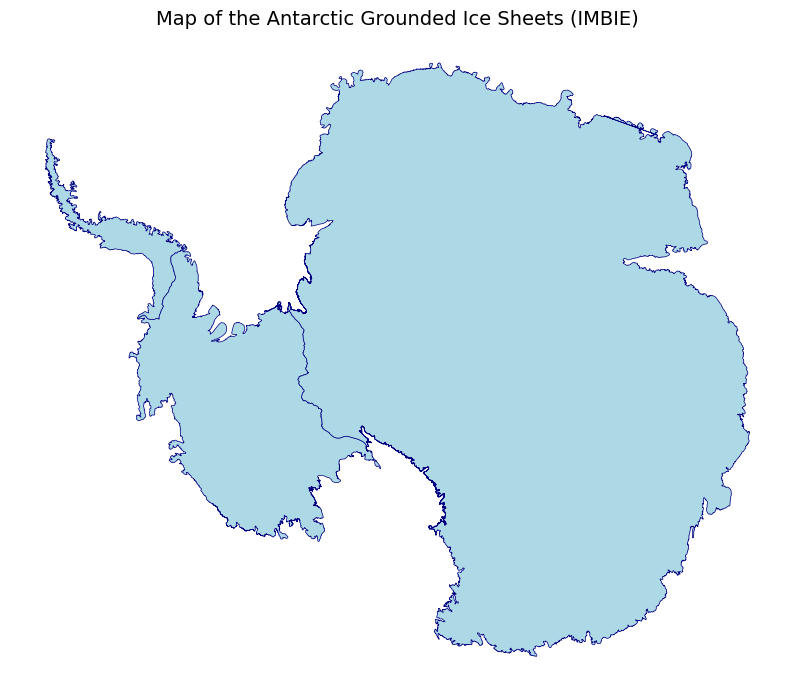

In [ ]:
# @title

import geopandas as gpd
from shapely.geometry import Polygon
import requests
import matplotlib.pyplot as plt
import numpy as np

def plot_antarctic_map():
    url_map = "https://imbie.org/wp-content/uploads/2016/08/Ant_Grounded_IceSheets_Polygon-1.txt"
    response = requests.get(url_map)

    if response.status_code != 200:
        print(f"Error: impossible to download the file. Code: {response.status_code}")
        return

    lines = response.text.splitlines()

    # Find the beginning of the data after "END OF HEADER"
    start_idx = 0
    for i, line in enumerate(lines):
        if line.strip().upper() == "END OF HEADER":
            start_idx = i + 1
            break

    coords = []      # (lon, lat)
    ids = []
    for line in lines[start_idx:]:
        clean_line = line.strip()
        if not clean_line:
            continue
        parts = clean_line.split()
        if len(parts) < 2:
            continue
        try:
            lat, lon = float(parts[0]), float(parts[1])
            id_ = parts[2] if len(parts) >= 3 else None
        except ValueError:
            continue
        coords.append((lon, lat))
        ids.append(id_)

    if not coords:
        print("Error: no valid coordinates found in the file.")
        return

# Build the rings: a new ring starts when the current point matches (within a given tolerance) the first point of the current ring, or when the basin ID changes.
    polygons = []
    current_ring = [coords[0]]
    ring_start = coords[0]

    for i in range(1, len(coords)):
        current_ring.append(coords[i])
        same_as_start = (
            abs(coords[i][0] - ring_start[0]) < 1e-6
            and abs(coords[i][1] - ring_start[1]) < 1e-6
        )
        id_changed = ids[i] != ids[i - 1] if ids[i] is not None else False

        if (same_as_start and len(current_ring) >= 4) or id_changed:
            if len(current_ring) >= 4:
                try:
                    polygons.append(Polygon(current_ring))
                except Exception:
                    pass
            current_ring = [coords[i]]
            ring_start = coords[i]

# Add the last remaining ring
    if len(current_ring) >= 4:
        try:
            polygons.append(Polygon(current_ring))
        except Exception:
            pass

    if not polygons:
        print("Error: no valid polygon built.")
        return

    gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
    gdf_polar = gdf.to_crs("EPSG:3031")

    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_polar.plot(ax=ax, color='lightblue', edgecolor='navy', linewidth=0.5)
    ax.set_title("Map of the Antarctic Grounded Ice Sheets (IMBIE)", fontsize=14)
    ax.set_axis_off()
    plt.show()

    return polygons

polygons = plot_antarctic_map()

**4. Interactive Antarctic map**

The following section creates the map-based visualization.

For each selected variable, the notebook calculates fixed colour limits across the full median time series of both scenarios. This makes maps from different years more directly comparable.

Users can select:

- the freshwater-flux variable;
- a year between 1990 and 2300;
- SSP126;
- SSP585;
- the difference `SSP585 − SSP126`.

A symmetric colour scale is used for the difference map so that positive and negative scenario differences can be compared around zero.

**Time-series view**

Use the variable dropdown and time-range slider to compare the evolution of SSP126 and SSP585.

- Solid lines represent the median projections.
- Shaded areas represent the 0.05–0.95 quantile interval.
- The horizontal axis represents the projection year.
- The vertical axis represents the selected freshwater-flux component.


**Map view**

Use the map controls to select a variable, year, and scenario.

The Antarctic polygon is coloured according to the selected whole-ice-sheet value. When the difference option is selected, the map displays:

`SSP585 − SSP126`

Positive values therefore indicate a larger projected value under SSP585, while negative values indicate a larger value under SSP126.


In [ ]:
import matplotlib.colors as mcolors
from shapely.ops import unary_union
import shapely.affinity

# Direct URL to Natural Earth
url_ne = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url_ne)
antarctica = world[world.NAME == "Antarctica"].copy()

# Robust dateline fix: shift, union, and shift back to remove the 180-degree seam
def fix_dateline(geom):
    # Shift geometry by 180 degrees to move the seam to the center, union it, then shift back
    shifted = shapely.affinity.translate(geom, xoff=180)
    merged = unary_union(shifted).buffer(0.0001).buffer(-0.0001)
    return shapely.affinity.translate(merged, xoff=-180)

healed_geom = fix_dateline(antarctica.geometry.iloc[0])
gdf_continent = gpd.GeoDataFrame(geometry=[healed_geom], crs="EPSG:4326")

# Project to Antarctic Polar Stereographic
gdf_continent_polar = gdf_continent.to_crs("EPSG:3031")

# Fixed color range logic
def compute_color_range(var):
    med_low = df_low[df_low['quantile'] == 0.50][var]
    med_high = df_high[df_high['quantile'] == 0.50][var]
    all_vals = pd.concat([med_low, med_high])
    return all_vals.quantile(0.02), all_vals.quantile(0.98)

def compute_diff_range(var):
    m_low = df_low[df_low['quantile'] == 0.50].set_index('time')[var]
    m_high = df_high[df_high['quantile'] == 0.50].set_index('time')[var]
    diff = (m_high - m_low).dropna()
    max_abs = diff.abs().max()
    return -max_abs, max_abs

def get_value(var, year, scenario):
    if scenario == "diff":
        v_low = df_low[(df_low['quantile'] == 0.50) & (df_low['time'] == year)][var]
        v_high = df_high[(df_high['quantile'] == 0.50) & (df_high['time'] == year)][var]
        return v_high.values[0] - v_low.values[0] if not (v_low.empty or v_high.empty) else None
    else:
        df = df_low if scenario == "low" else df_high
        v = df[(df['quantile'] == 0.50) & (df['time'] == year)][var]
        return v.values[0] if not v.empty else None

map_scenario = widgets.Dropdown(options=[("Low Emissions (SSP126)", "low"), ("High Emissions (SSP585)", "high"), ("Difference High - Low", "diff")], value="low", description="Scenario:")
map_variable = widgets.Dropdown(options=columns_to_plot, value=columns_to_plot[0], description="Variable:")
map_year_slider = widgets.IntSlider(value=1990, min=1990, max=2300, step=1, description="Year:", continuous_update=False, layout={'width': '500px'})
map_output = widgets.Output()

def draw_detail_box(ax, value, unit="Gt/yr"):
    year, var = map_year_slider.value, map_variable.value
    label = {v: l for l, v in map_scenario.options}.get(map_scenario.value, "N/D")
    val_txt = f"{value:.2f}" if value is not None else "N/D"
    ax.text(0.02, 0.98, f"Antarctic Ice Sheet (Total)\nScenario: {label}\nVariable: {var}\nYear: {year}\nValue: {val_txt} {unit}",
            transform=ax.transAxes, fontsize=10, va="top", ha="left", bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "edgecolor": "black", "alpha": 0.85})

def draw_map(change=None):
    var, scenario, year = map_variable.value, map_scenario.value, map_year_slider.value
    with map_output:
        clear_output(wait=True)
        value = get_value(var, year, scenario)
        gdf_plot = gdf_continent_polar.copy()
        gdf_plot["value"] = value
        vmin, vmax = compute_diff_range(var) if scenario == "diff" else compute_color_range(var)
        cmap = "RdBu_r" if scenario == "diff" else ("RdBu" if "Mass_Balance" in var else "YlOrRd")
        fig, ax = plt.subplots(figsize=(10, 10))
        # Removing edgecolor entirely to hide the seam line at 180 degrees
        gdf_plot.plot(column="value", ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, legend=True,
                      legend_kwds={"label": f"{var} (Gt/yr)", "orientation": "vertical", "shrink": 0.5},
                      edgecolor="none")
        draw_detail_box(ax, value)
        ax.set_title(f"Year {year} - {var}", fontsize=14)
        ax.set_axis_off()
        plt.show()

map_scenario.observe(draw_map, names="value")
map_variable.observe(draw_map, names="value")
map_year_slider.observe(draw_map, names="value")
display(widgets.VBox([widgets.HTML("<h4>Antarctic map - Freshwater Flux</h4>"), widgets.HBox([map_scenario, map_variable]), map_year_slider, map_output]))
draw_map()

**Interpretation guidance**

The time series represent the Antarctic Ice Sheet as a single spatial aggregate. They do not show differences among drainage basins, ice-sheet sectors, or receiving ocean regions.

The Antarctic map provides geographic context for the aggregate value but does not spatially distribute the projection across the continent. Every polygon is assigned the same whole-ice-sheet value for the selected year and scenario. It should therefore not be interpreted as a basin-level or grid-cell projection.

Differences between SSP126 and SSP585 should be assessed together with the uncertainty intervals. A visible difference between the median curves does not necessarily imply that the scenarios are clearly separated throughout the full uncertainty range.

The sign and units of each variable should be confirmed from the ERDDAP metadata before combining variables or comparing them with external estimates.


**Additional resources and acknowledgement**

Python libraries used in this notebook:

- [pandas](https://pandas.pydata.org/docs/) for data processing
- [matplotlib](https://matplotlib.org/stable/index.html) for plotting
- [ipywidgets](https://ipywidgets.readthedocs.io/) for interactive control.
- [GeoPandas](https://geopandas.org/en/stable/docs.html) and [Shapely](https://shapely.readthedocs.io/en/stable/) for Antarctic geometry processing;
- [requests](https://requests.readthedocs.io/en/latest/) for downloading the external boundary file;
- [NumPy](https://numpy.org/) and [matplotlib](https://matplotlib.org/stable/index.html) for colour-scale calculations.

This work has received funding from the European Union Horizon Europe project **OCEAN:ICE (Ocean-Cryosphere Exchanges in ANtarctica: Impacts on Climate and the Earth System)** under Grant Agreement No. 101060452. The datasets are distributed through the OCEAN:ICE ERDDAP infrastructure.

<center>
  <div style="display: flex; justify-content: center; align-items: flex-start; gap: 80px;">
    <img src="https://ocean-ice.eu/wp-content/uploads/2025/02/TO-USE-RGB-for-digital-materials-V.png" height="140" style="margin-top: 50px;"/>
    <img src="https://ocean-ice.eu/wp-content/uploads/2025/02/UKRI-logo-1.png" height="100"/>
    <img src="https://ocean-ice.eu/wp-content/uploads/2023/06/logo-polar-cluster-2.png" height="100"/>
  </div>
</center>